Dataset Found:
/kaggle/input/datasets/merajsharif/smart-city/urban_connectivity.csv
(102, 79)
                                      count      mean       std       min  \
Walkable_Park_Access_white             98.0  0.726652  0.179425  0.326380   
Walkable_Park_Access_black             98.0  0.745054  0.164212  0.392388   
Walkable_Park_Access_hispanic_latinx   98.0  0.744438  0.167073  0.283680   
Walkable_Park_Access_asian             98.0  0.714497  0.199188  0.242177   

                                           25%       50%       75%       max  
Walkable_Park_Access_white            0.612396  0.733475  0.877466  0.998129  
Walkable_Park_Access_black            0.621588  0.748640  0.886882  0.999268  
Walkable_Park_Access_hispanic_latinx  0.649105  0.755744  0.871530  0.998801  
Walkable_Park_Access_asian            0.595370  0.736801  0.895028  0.996952  


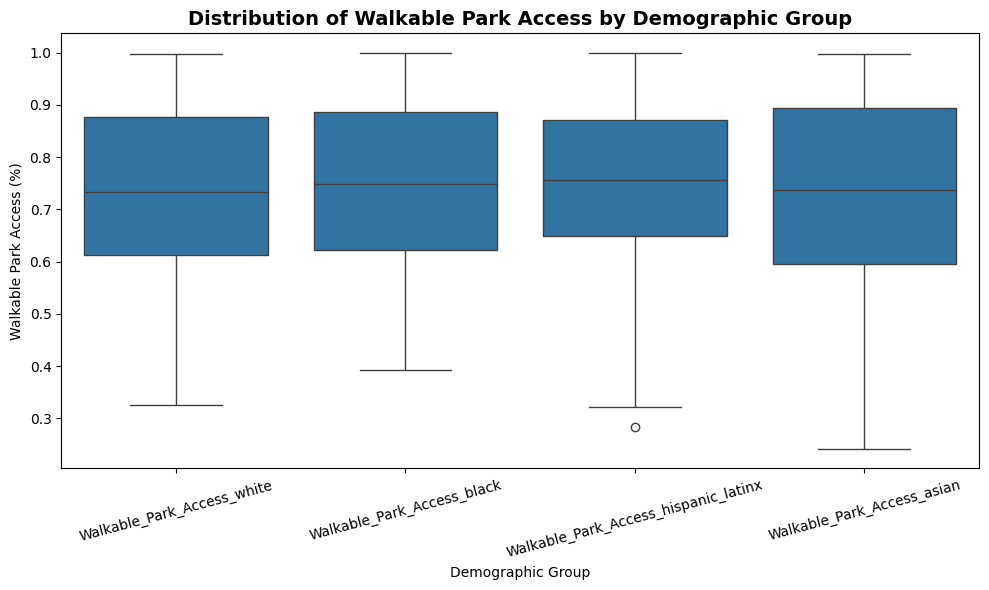

RQ3 Completed


In [1]:
# =====================================================
# RQ3
# Are all demographic groups equally served
# by urban green infrastructure?
# =====================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path
import shutil

# =====================================================
# FIND DATASET
# =====================================================

connectivity_file = None

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if filename == "urban_connectivity.csv":
            connectivity_file = os.path.join(dirname, filename)

print("Dataset Found:")
print(connectivity_file)

# =====================================================
# LOAD DATA
# =====================================================

connectivity = pd.read_csv(connectivity_file)

print(connectivity.shape)

# =====================================================
# OUTPUT FOLDER
# =====================================================

output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)

# =====================================================
# COLUMNS
# =====================================================

park_cols = [
    "Walkable_Park_Access_white",
    "Walkable_Park_Access_black",
    "Walkable_Park_Access_hispanic_latinx",
    "Walkable_Park_Access_asian"
]

# =====================================================
# TABLE
# =====================================================

rq3_table = connectivity[park_cols].describe().T

rq3_table.to_csv(
    output_dir / "RQ3_Park_Access_Demographics.csv"
)

print(rq3_table)

# =====================================================
# BOXPLOT
# =====================================================

plot_df = connectivity[park_cols].melt(
    var_name="Demographic_Group",
    value_name="Park_Access"
)

plt.figure(figsize=(10,6))

sns.boxplot(
    data=plot_df,
    x="Demographic_Group",
    y="Park_Access"
)

plt.title(
    "Distribution of Walkable Park Access by Demographic Group",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Demographic Group")
plt.ylabel("Walkable Park Access (%)")

plt.xticks(rotation=15)

plt.tight_layout()

plt.savefig(
    output_dir / "RQ3_Park_Access_Demographics.pdf",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

# =====================================================
# ZIP
# =====================================================

shutil.make_archive(
    "/kaggle/working/RQ3_Output",
    "zip",
    "outputs"
)

print("RQ3 Completed")